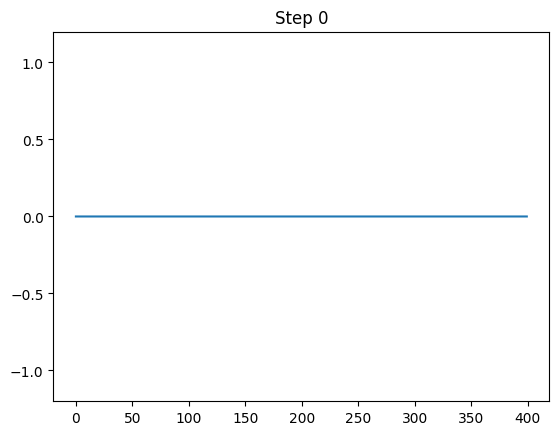

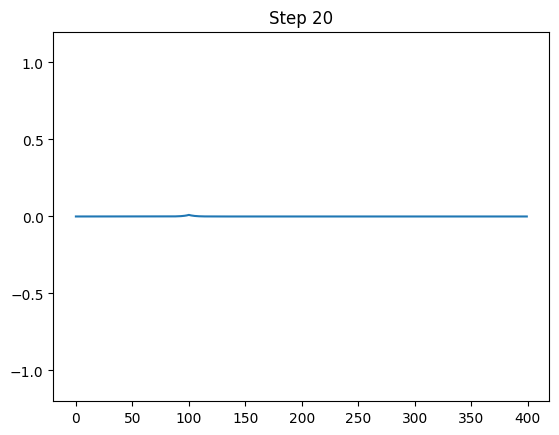

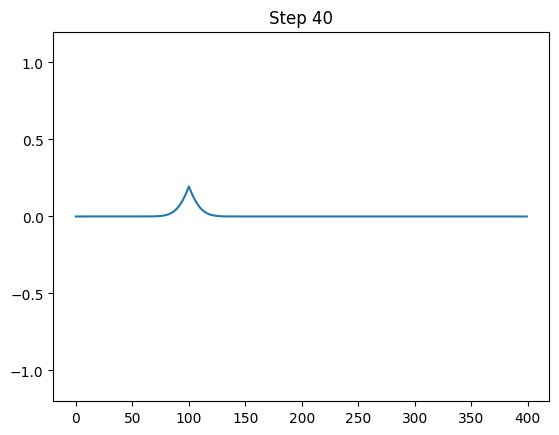

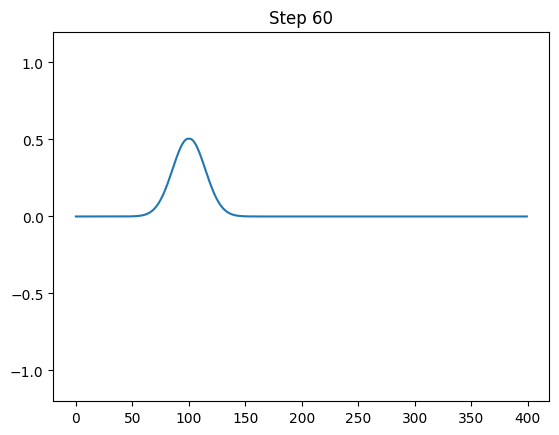

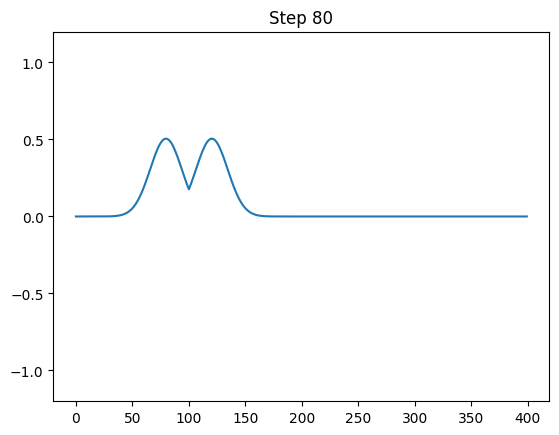

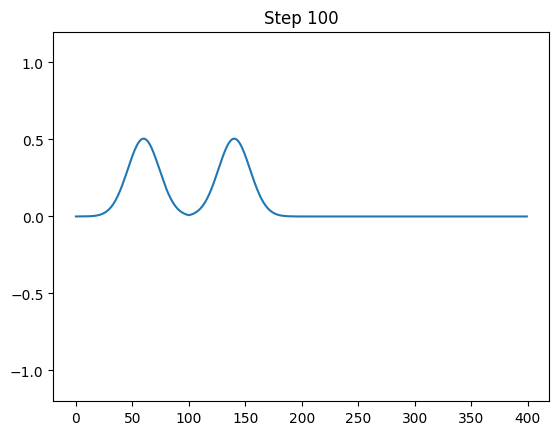

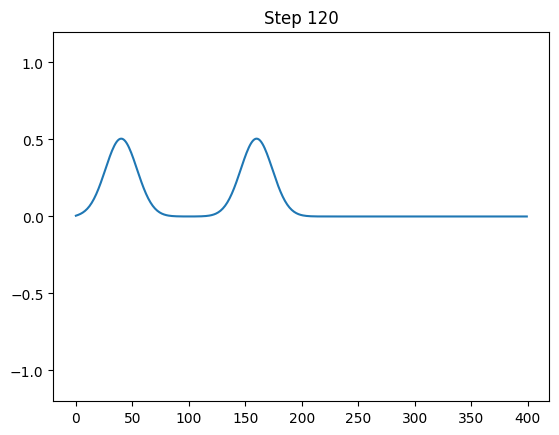

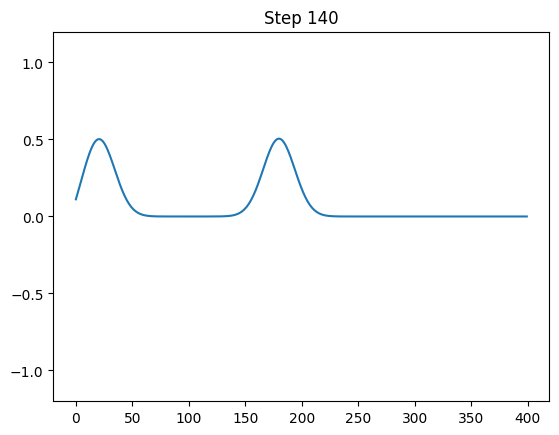

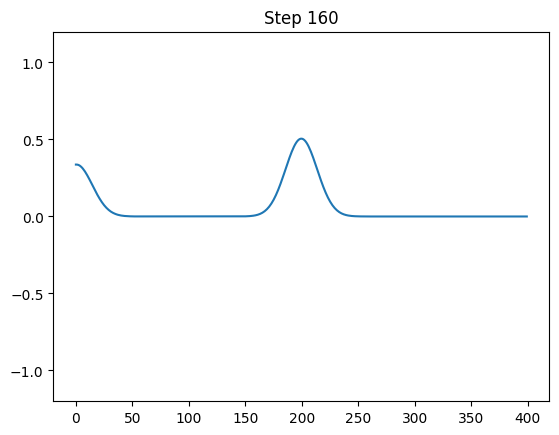

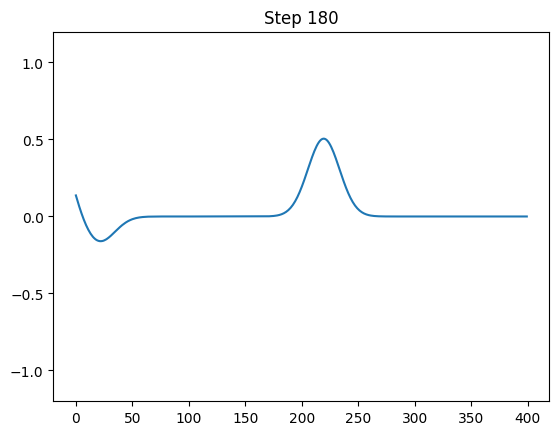

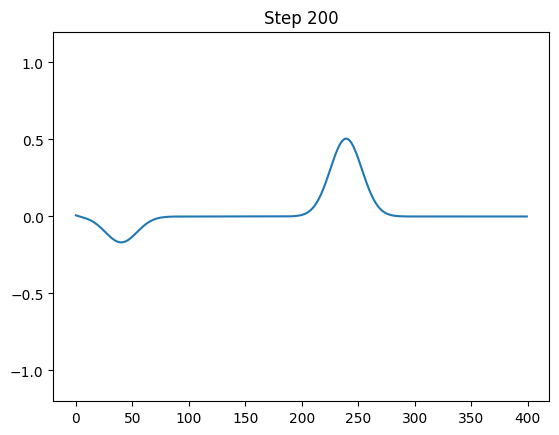

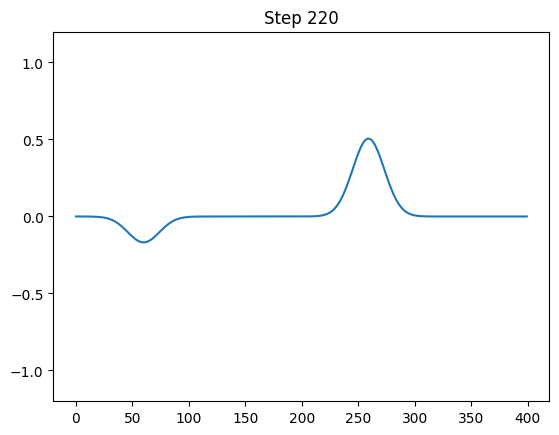

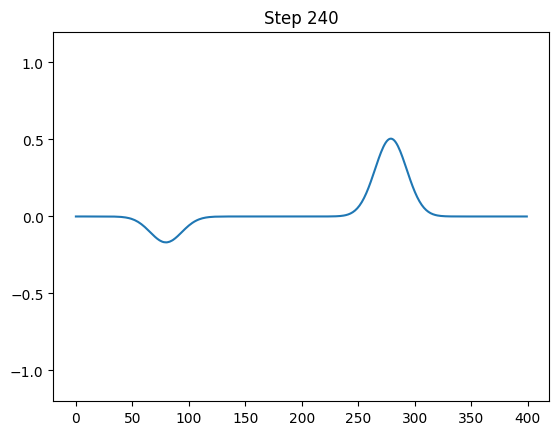

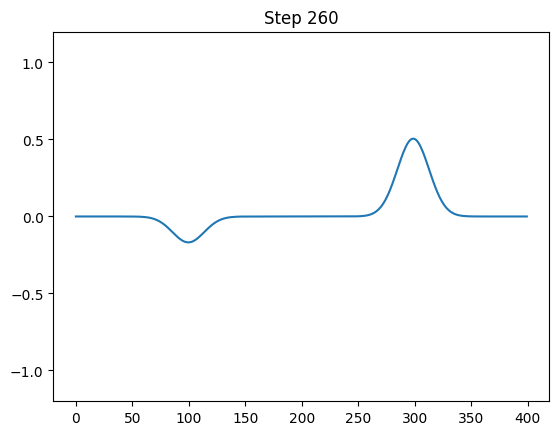

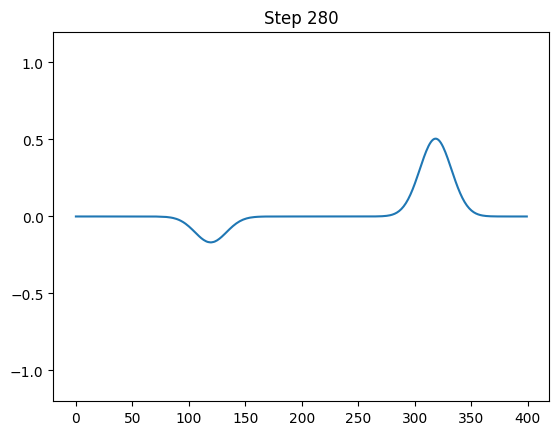

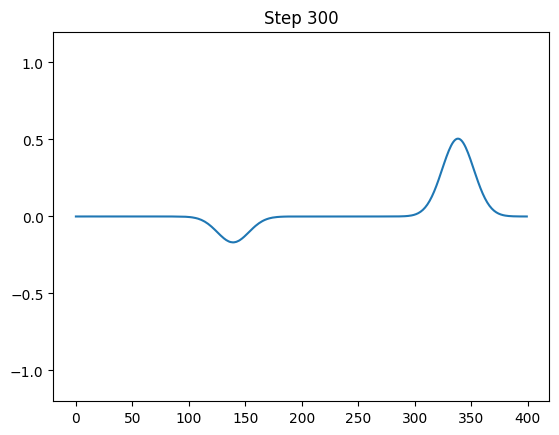

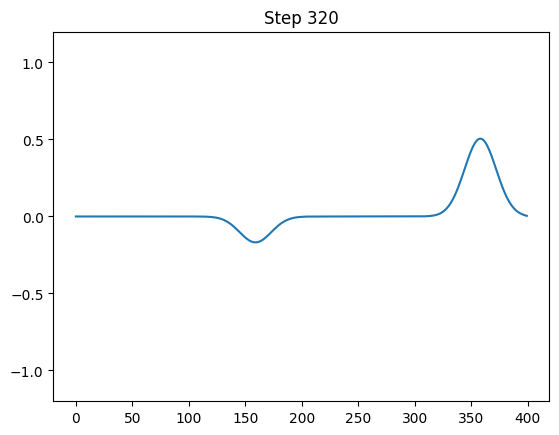

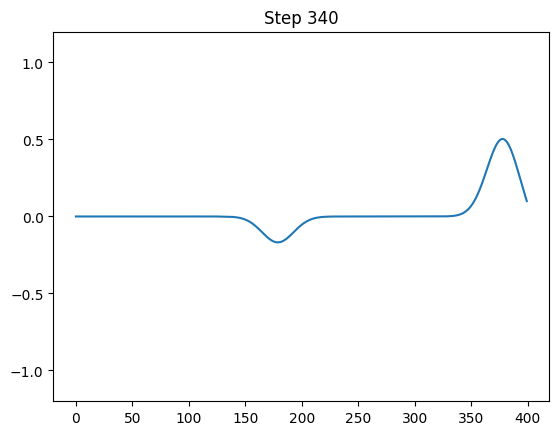

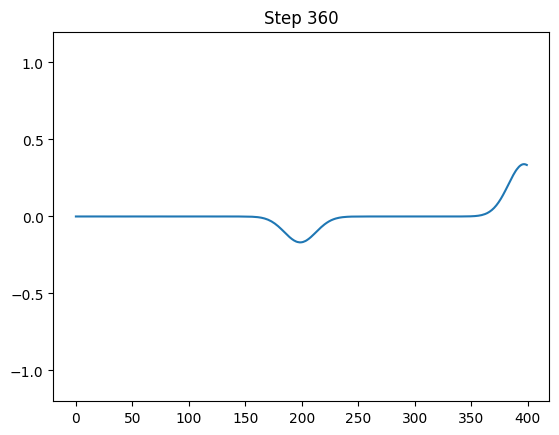

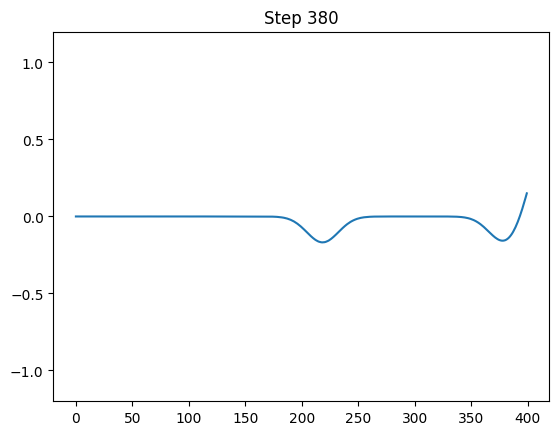

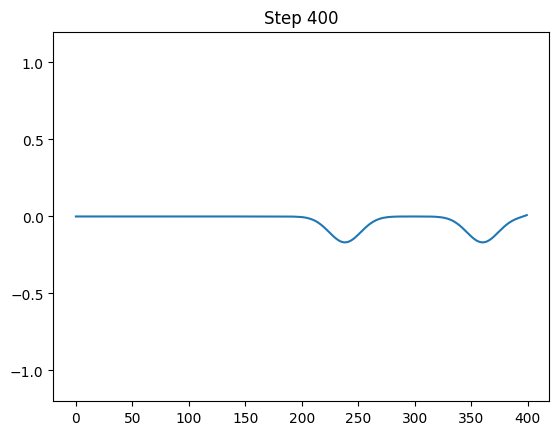

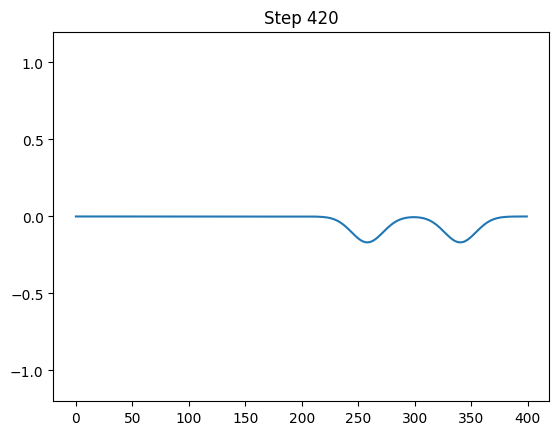

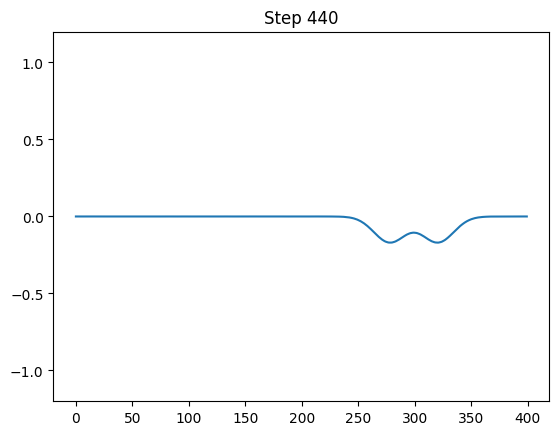

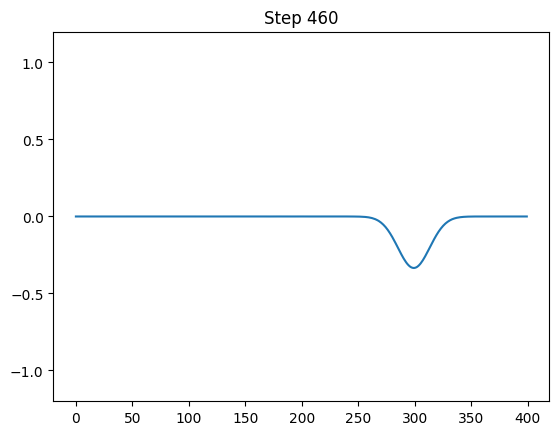

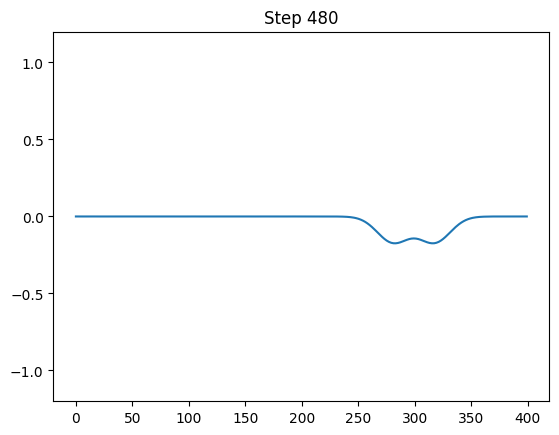

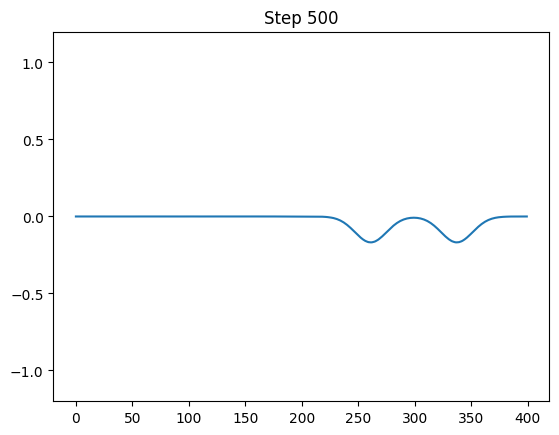

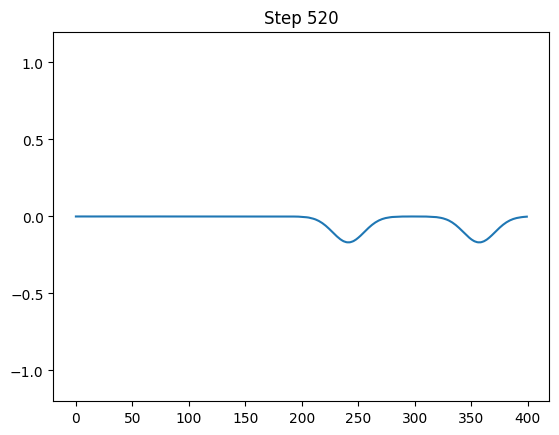

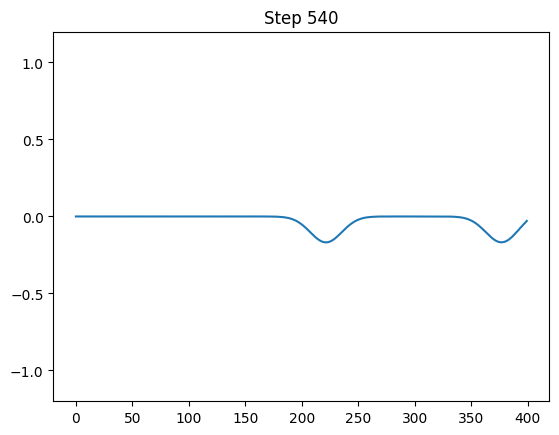

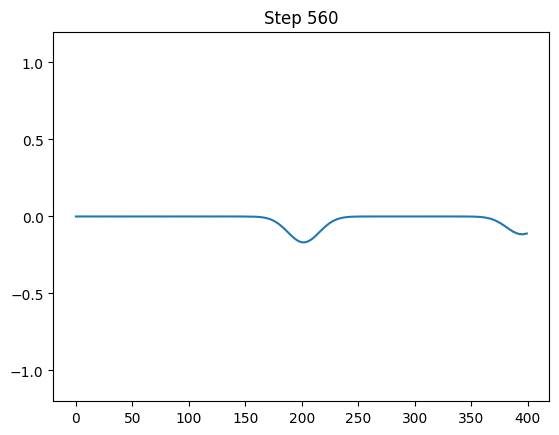

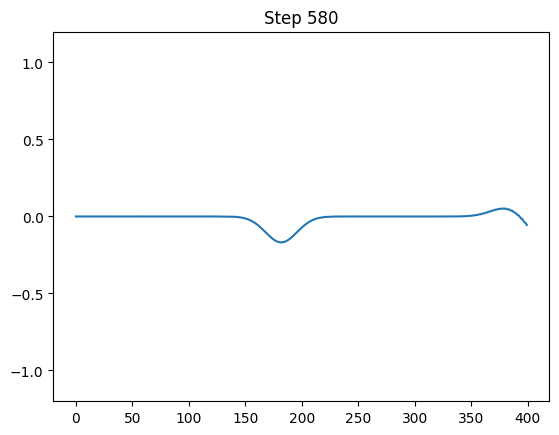

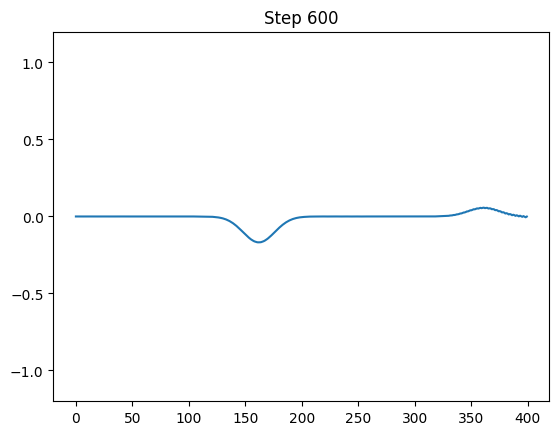

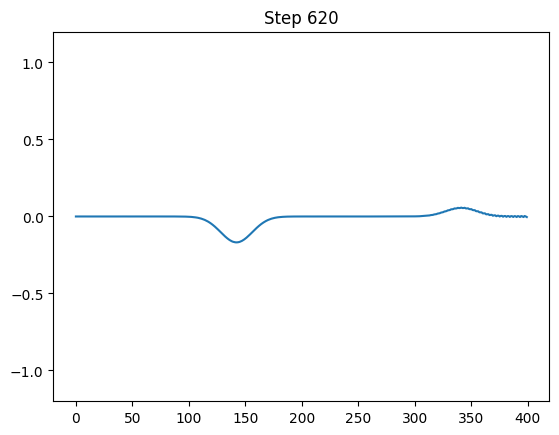

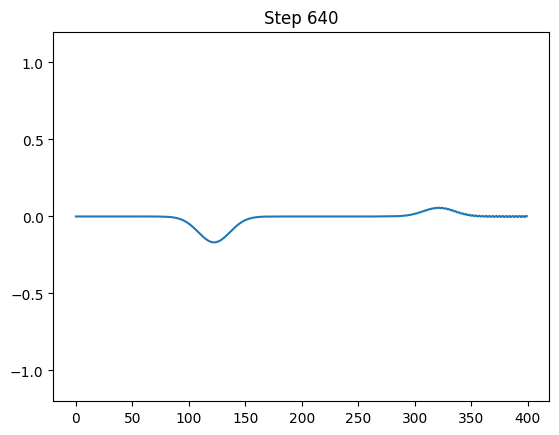

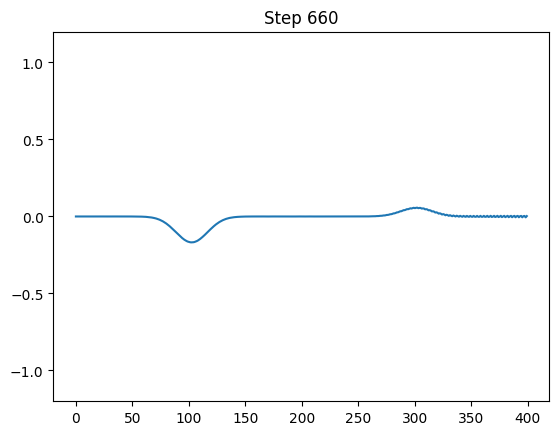

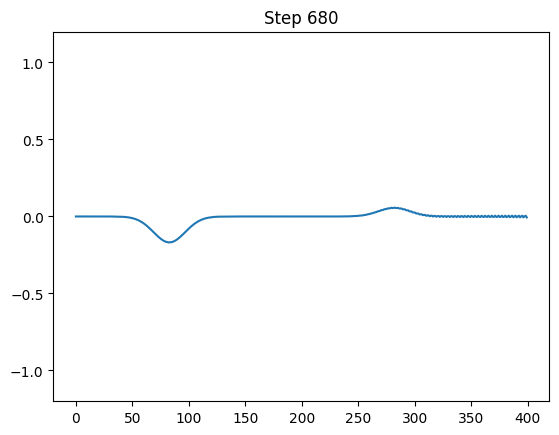

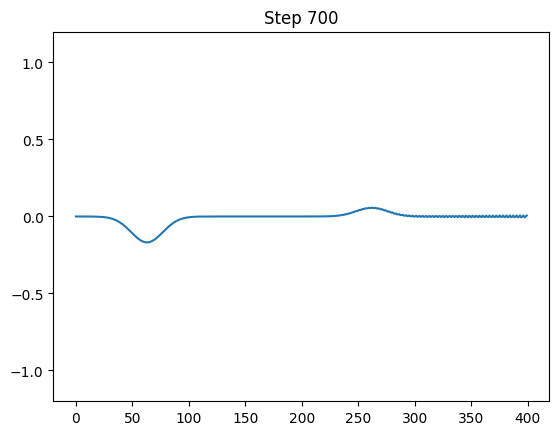

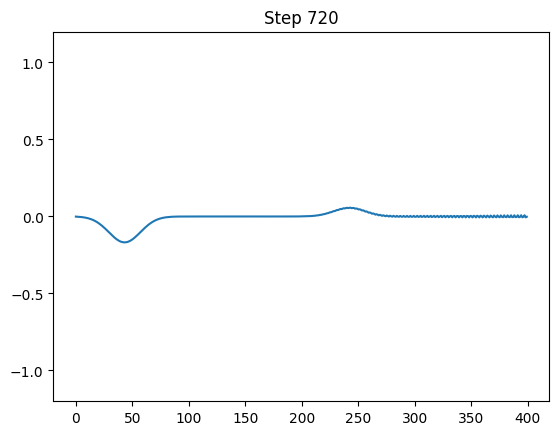

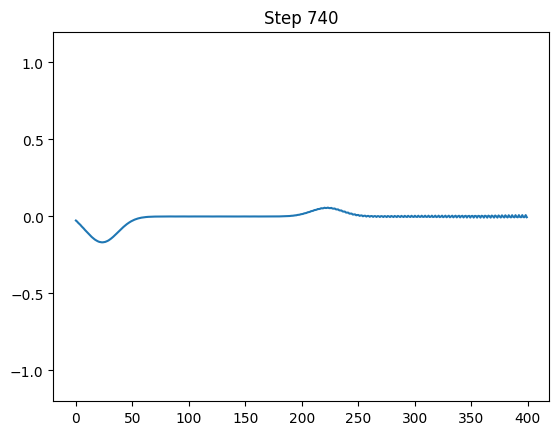

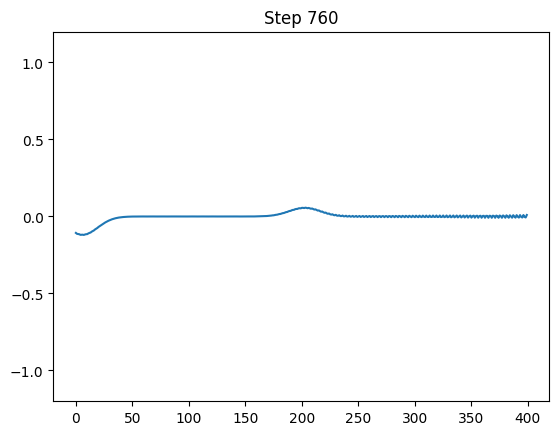

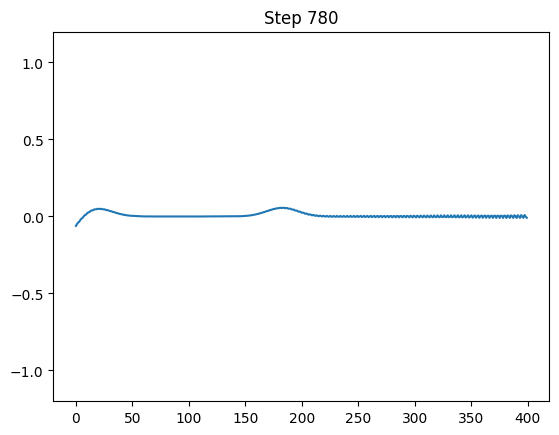

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Constants (free space)
# -----------------------------
c = 299792458.0
mu0 = 4e-7 * np.pi
eps0 = 1.0 / (mu0 * c**2)

# -----------------------------
# Grid
# -----------------------------
Nx = 400
dx = 1e-3
dt = dx / c * 0.99  # CFL

Nt = 800

# -----------------------------
# Field arrays
# -----------------------------
E_curr = np.zeros(Nx)
E_next = np.zeros(Nx)

H_curr = np.zeros(Nx-1)
H_next = np.zeros(Nx-1)

# -----------------------------
# Mur storage (previous time step)
# -----------------------------
E_left_old = 0.0
E_right_old = 0.0

coef = (c*dt - dx) / (c*dt + dx)

# -----------------------------
# Source
# -----------------------------
def source(t):
    t0 = 60
    spread = 20
    return np.exp(-((t - t0)/spread)**2)

src_pos = Nx // 4

# -----------------------------
# Time loop
# -----------------------------
for n in range(Nt):

    # --- Update H_next from E_curr ---
    H_next[:] = H_curr[:] + (dt / (mu0 * dx)) * (E_curr[1:] - E_curr[:-1])

    # --- Update E_next from H_next ---
    E_next[1:-1] = E_curr[1:-1] + (dt / (eps0 * dx)) * (
        H_next[1:] - H_next[:-1]
    )

    # --- Source (soft) ---
    E_next[src_pos] += source(n)

    # -----------------------------
    # Mur 1st order ABC
    # -----------------------------
    # Left boundary
    E_next[0] = E_left_old + coef * (E_next[1] - E_curr[0])
    E_left_old = E_curr[1]

    # Right boundary
    E_next[-1] = E_right_old + coef * (E_next[-2] - E_curr[-1])
    E_right_old = E_curr[-2]

    # -----------------------------
    # Swap buffers
    # -----------------------------
    E_curr, E_next = E_next, E_curr
    H_curr, H_next = H_next, H_curr

    # -----------------------------
    # Visualization
    # -----------------------------
    if n % 20 == 0:
        plt.clf()
        plt.plot(E_curr)
        plt.ylim(-1.2, 1.2)
        plt.title(f"Step {n}")
        plt.pause(0.01)

plt.show()